In [76]:
import numpy as np
import seaborn as sns
from matplotlib import gridspec
import matplotlib.pyplot as plt
from esg.models import SmithWilson

In [77]:
# 환경설정
plt.style.use('default')
plt.rc('figure', figsize=(10, 5))
plt.rc('axes', unicode_minus=False)
plt.rc('font', family='Malgun Gothic')
plt.style.use('seaborn')

In [78]:
# 데이터 입력
data = np.array([
    [1, 0.00656],
    [2, 0.00886],
    [3, 0.00970],
    [5, 0.01335],
    [10, 0.01722],
    [20, 0.01832]
])
X_train = data[:, 0]
y_train = data[:, 1]
ltfr, terminal = 0.052, 60

# SW 모델 생성 및 α 학습
sw = SmithWilson(np.log(1+ltfr), terminal)
sw.train(X_train, y_train)

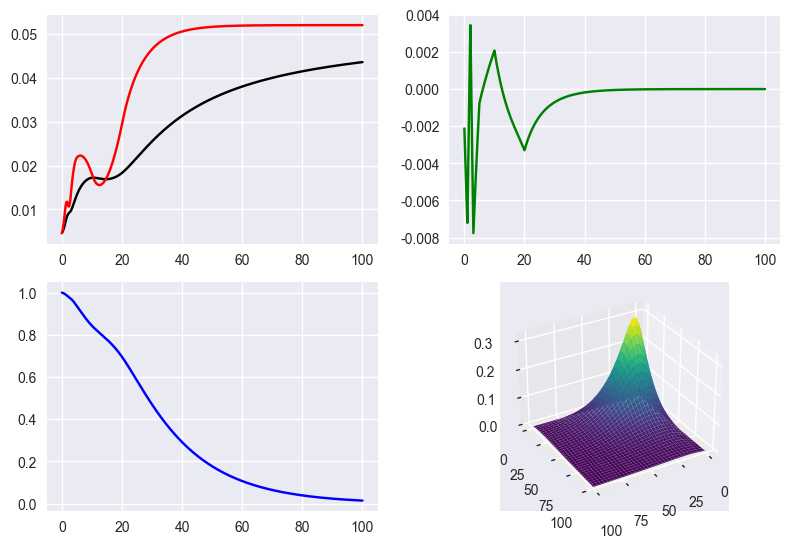

In [94]:
fig = plt.figure()
gs = gridspec.GridSpec(2, 2)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1], projection='3d')


t = np.arange(0, 100+1e-6, 1/12)
r = sw.spot(t)
f = sw.forward(t)
f2 = sw.forward(t, order=1)
p = sw.bond(t)
ax00.plot(t, r, c='black')
ax00.plot(t, f, c='red')
ax01.plot(t, f2, c='green')
ax10.plot(t, p, c='blue')

x = np.arange(0, 101)
X = np.tile(x, (101, 1))
Y = np.transpose(X)
Z = sw._wilson(X, Y, sw._alpha)
ax11.plot_surface(X, Y, Z, cmap='viridis')
ax11.view_init(30, 60)

fig.tight_layout()
plt.show()